In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import requests
from io import BytesIO
import os

import torch

In [ ]:
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")

PyTorch: 2.10.0+cu128
CUDA: True


In [ ]:
"""
BOUNDING BOX FORMATS
====================

1. XYXY (corners): [x_min, y_min, x_max, y_max]
   ┌──────────────────┐
   │(x_min, y_min)    │
   │   ┌─────────┐    │
   │   │  Object │    │
   │   └─────────┘    │
   │        (x_max, y_max)
   └──────────────────┘

2. XYWH (center + size): [x_center, y_center, width, height]

3. XYWH (corner + size): [x_min, y_min, width, height]


NORMALIZATION:
  • Absolute: pixels (e.g., [100, 50, 200, 150])
  • Normalized: 0-1 (e.g., [0.1, 0.05, 0.2, 0.15])

"""

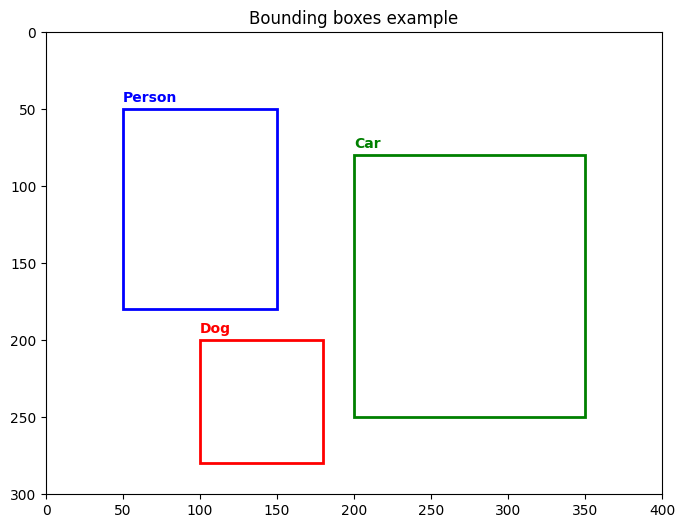

In [ ]:
#Visualizing a bounding box
def draw_bbox(ax, box, label, color='red', format='xyxy'):
  if format == 'xyxy':
    x1, y1, x2, y2 = box
    w, h = x2 - x1, y2 - y1
  elif format == 'xywh_corner':
    x1, y1, w, h = box
  elif format == 'xywh_corner':
    cx, cy, w, h = box
    x1, y1 = cx - w/2, cy - h/2

  rect = patches.Rectangle((x1, y1), w, h, linewidth=2, edgecolor=color, facecolor='None')
  ax.add_patch(rect)
  ax.text(x1, y1 - 5, label, color=color, fontsize=10, weight='bold')

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xlim(0, 400)
ax.set_ylim(0, 300)
ax.set_aspect('equal')
ax.invert_yaxis()

#drawing sample boxes
draw_bbox(ax, [50, 50, 150, 180], 'Person', 'blue')
draw_bbox(ax, [200, 80, 350, 250], 'Car', 'green')
draw_bbox(ax, [100, 200, 180, 280], 'Dog', 'red')

ax.set_title("Bounding boxes example")
plt.show()

In [ ]:
"""
IoU (Intersection over Union)
=============================

How do we measure if a predicted box is "correct"?

        ┌───────────┐
        │  Ground   │
        │  Truth    │
        │    ┌──────┼─────┐
        │    │ INTER│     │
        └────┼──────┘     │
             │  Prediction│
             └────────────┘

IoU = Area of Intersection / Area of Union

  • IoU = 1.0: Perfect overlap
  • IoU = 0.0: No overlap
  • IoU > 0.5: Usually considered "correct"

Used for:
  • Matching predictions to ground truth
  • Non-Max Suppression (NMS)
  • Calculating mAP
"""

In [ ]:
# Implement IoU
def calculate_iou(box1, box2):
    """Calculate IoU between two boxes in xyxy format."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    # Intersection
    inter_width = max(0, x2 - x1)
    inter_height = max(0, y2 - y1)
    intersection = inter_width * inter_height

    # Union
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0

# Test
gt_box = [100, 100, 200, 200]  # Ground truth
pred_good = [110, 110, 210, 210]  # Good prediction
pred_bad = [250, 250, 350, 350]  # Bad prediction

print(f"IoU (good prediction): {calculate_iou(gt_box, pred_good):.2f}")
print(f"IoU (bad prediction): {calculate_iou(gt_box, pred_bad):.2f}")

IoU (good prediction): 0.68
IoU (bad prediction): 0.00


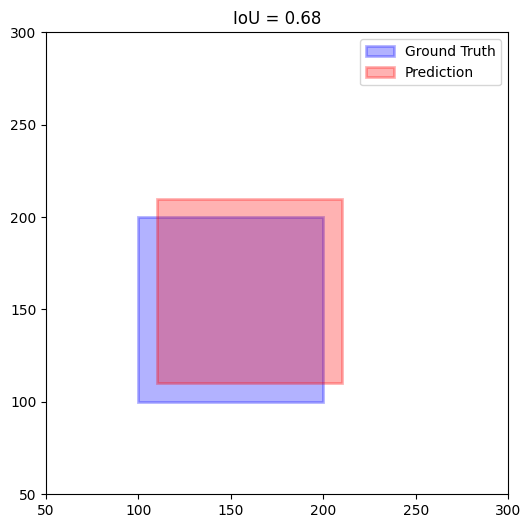

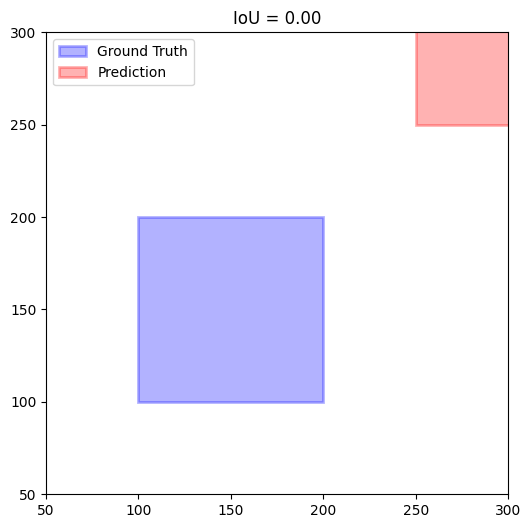

In [ ]:
# Visualize IoU
def visualize_iou(box1, box2):
    fig, ax = plt.subplots(figsize=(8, 6))

    # Box 1 (Ground Truth)
    rect1 = patches.Rectangle((box1[0], box1[1]), box1[2]-box1[0], box1[3]-box1[1],
                                linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.3)
    ax.add_patch(rect1)

    # Box 2 (Prediction)
    rect2 = patches.Rectangle((box2[0], box2[1]), box2[2]-box2[0], box2[3]-box2[1],
                                linewidth=2, edgecolor='red', facecolor='red', alpha=0.3)
    ax.add_patch(rect2)

    iou = calculate_iou(box1, box2)

    ax.set_xlim(50, 300)
    ax.set_ylim(50, 300)
    ax.set_aspect('equal')
    ax.legend(['Ground Truth', 'Prediction'])
    ax.set_title(f'IoU = {iou:.2f}')
    plt.show()

visualize_iou(gt_box, pred_good)
visualize_iou(gt_box, pred_bad)

In [ ]:
"""
Object Detection Architectures

TWO-STAGE DETECTORS (Accurate but slow)
─────────────────────────────────────────
Step 1: Propose regions ("where might objects be?")
Step 2: Classify each region

• R-CNN (2014): Selective Search → CNN → SVM
• Fast R-CNN (2015): Share CNN features
• Faster R-CNN (2016): Region Proposal Network (RPN)

  Image → Backbone → RPN → RoI Pooling → Classifier
                      ↓
                 Proposals

ONE-STAGE DETECTORS (Fast, good for real-time)
─────────────────────────────────────────
Directly predict boxes and classes in one pass.

• YOLO (2016): "You Only Look Once" — single pass
• SSD (2016): Multi-scale feature maps
• RetinaNet (2017): Focal loss for imbalance
• YOLOv8 (2023): State-of-the-art, easy to use

  Image → Backbone → Neck → Head → Boxes + Classes
                              (one pass!)
"""

In [ ]:
"""
YOLO (You Only Look Once)
=========================

Key idea: Treat detection as a REGRESSION problem.

1. Divide image into SxS grid (e.g., 7x7)
2. Each grid cell predicts:
   • B bounding boxes (x, y, w, h, confidence)
   • C class probabilities
3. Single forward pass → all predictions

  ┌───┬───┬───┬───┬───┬───┬───┐
  │   │   │   │   │   │   │   │
  ├───┼───┼───┼───┼───┼───┼───┤
  │   │   │ 🚗│   │   │   │   │  ← This cell predicts the car
  ├───┼───┼───┼───┼───┼───┼───┤
  │   │   │   │   │ 🐕│   │   │  ← This cell predicts the dog
  ├───┼───┼───┼───┼───┼───┼───┤
  │   │   │   │   │   │   │   │
  └───┴───┴───┴───┴───┴───┴───┘

YOLOv8 IMPROVEMENTS:
  • Anchor-free detection
  • Better backbone (CSPDarknet)
  • Feature Pyramid Network (FPN)
  • Decoupled head (separate class/box prediction)
  • Easy-to-use Ultralytics library
"""

In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO

In [ ]:
model = YOLO('yolov8n.pt')

#small but fast

In [ ]:
# COCO classes
coco_classes = [
    'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
    'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat',
    'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
    'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
    'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse',
    'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]
print(f"COCO has {len(coco_classes)} classes")
print(f"Examples: {coco_classes[:10]}...")

COCO has 80 classes
Examples: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']...


Running inference on sample images

In [ ]:
sample_urls = [
    "https://ultralytics.com/images/bus.jpg",
    "https://ultralytics.com/images/zidane.jpg"
]

os.makedirs('sample_images', exist_ok=True)

for i, url in enumerate(sample_urls):
  response = requests.get(url)
  img = Image.open(BytesIO(response.content))
  img.save(f"sample_images/sample_{i}.jpg")

print("Images download")

Images download


In [ ]:
results = model('sample_images/sample_0.jpg')

print("results: ")
for r in results:
  boxes = r.boxes
  for box in boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print(f" {coco_classes[cls]} ({conf:.2f}): {xyxy}")



image 1/1 /content/sample_images/sample_0.jpg: 640x480 4 persons, 1 bus, 88.7ms
Speed: 2.8ms preprocess, 88.7ms inference, 19.4ms postprocess per image at shape (1, 3, 640, 480)
results: 
 bus (0.87): [22.898202896118164, 231.35154724121094, 805.158447265625, 757.7848510742188]
 person (0.87): [48.616798400878906, 398.68731689453125, 245.53379821777344, 902.5955810546875]
 person (0.85): [669.491943359375, 392.527099609375, 809.7255859375, 876.6099243164062]
 person (0.83): [221.42648315429688, 405.7920837402344, 344.99444580078125, 857.906494140625]
 person (0.26): [0.0, 550.3700561523438, 62.9726448059082, 873.662841796875]



image 1/1 /content/sample_images/sample_1.jpg: 384x640 2 persons, 1 tie, 73.5ms
Speed: 1.9ms preprocess, 73.5ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)


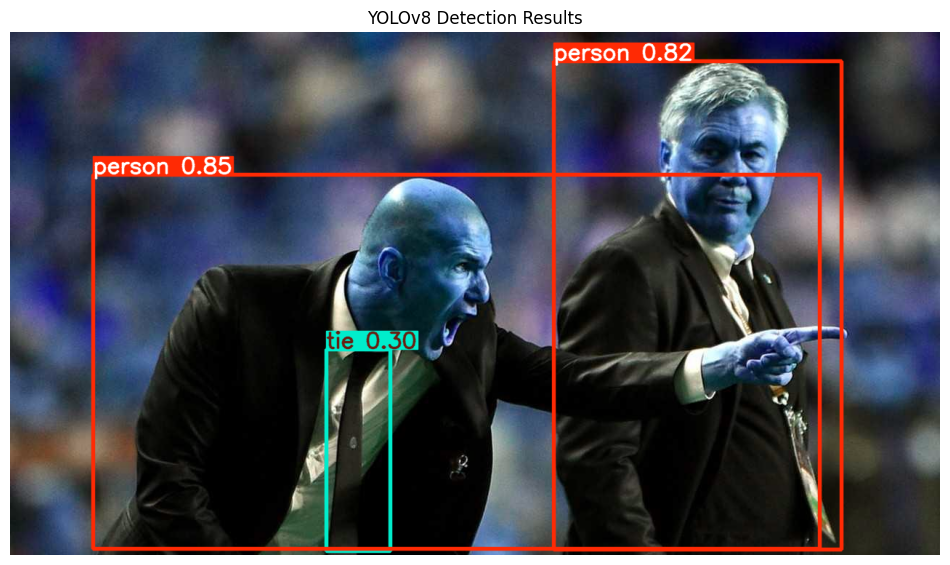

  person: 84.77%
  person: 82.22%
  tie: 29.54%


In [ ]:
# Second image
results = model('sample_images/sample_1.jpg')

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(results[0].plot())
ax.axis('off')
ax.set_title('YOLOv8 Detection Results')
plt.show()

# Print detections
for r in results:
    for box in r.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        print(f"  {coco_classes[cls]}: {conf:.2%}")

In [ ]:
# Detailed look at results structure
results = model('sample_images/sample_1.jpg')

r = results[0]

print("Results Structure:")
print("="*50)
print(f"\nImage shape: {r.orig_shape}")
print(f"Number of detections: {len(r.boxes)}")

print("\nFor each detection:")
for i, box in enumerate(r.boxes):
    print(f"\n  Detection {i+1}:")
    print(f"    Class: {coco_classes[int(box.cls[0])]}")
    print(f"    Confidence: {float(box.conf[0]):.4f}")
    print(f"    Box (xyxy): {box.xyxy[0].tolist()}")
    print(f"    Box (xywh): {box.xywh[0].tolist()}")


image 1/1 /content/sample_images/sample_1.jpg: 384x640 2 persons, 1 tie, 8.8ms
Speed: 1.9ms preprocess, 8.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
Results Structure:

Image shape: (720, 1280)
Number of detections: 3

For each detection:

  Detection 1:
    Class: person
    Confidence: 0.8477
    Box (xyxy): [114.0966796875, 197.4549560546875, 1114.776611328125, 711.87255859375]
    Box (xywh): [614.4366455078125, 454.66375732421875, 1000.679931640625, 514.4176025390625]

  Detection 2:
    Class: person
    Confidence: 0.8222
    Box (xyxy): [748.630615234375, 41.8067626953125, 1144.1058349609375, 712.8841552734375]
    Box (xywh): [946.3682250976562, 377.345458984375, 395.4752197265625, 671.077392578125]

  Detection 3:
    Class: tie
    Confidence: 0.2954
    Box (xyxy): [435.9444580078125, 437.426513671875, 523.4927978515625, 714.6962890625]
    Box (xywh): [479.7186279296875, 576.0614013671875, 87.54833984375, 277.269775390625]


Upload an image to test:


Saving swans-swimming-together-on-a-cloudy-day.jpg to swans-swimming-together-on-a-cloudy-day.jpg

Running detection on swans-swimming-together-on-a-cloudy-day.jpg...

image 1/1 /content/swans-swimming-together-on-a-cloudy-day.jpg: 384x640 7 birds, 9.4ms
Speed: 2.9ms preprocess, 9.4ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)


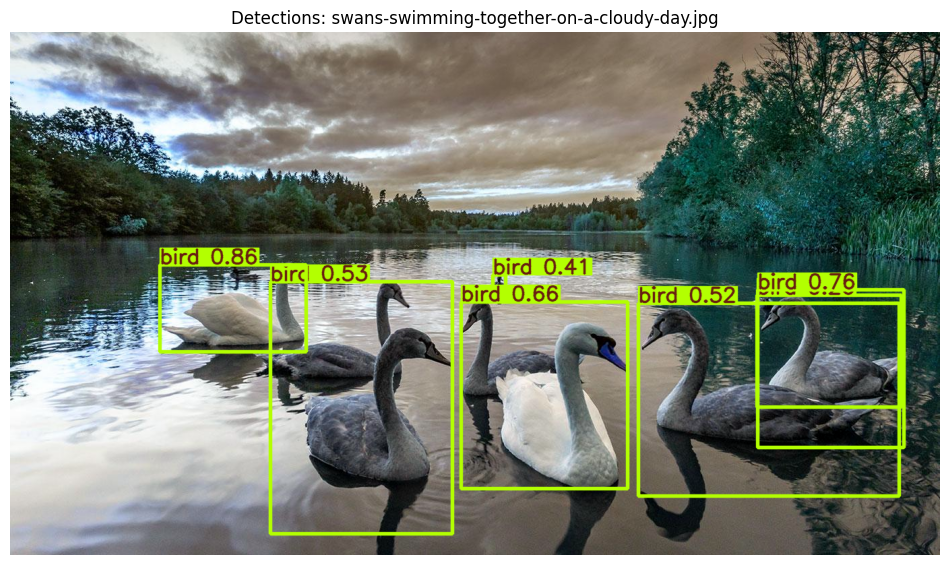


Detected objects:
  bird: 86.27%
  bird: 76.33%
  bird: 66.22%
  bird: 52.51%
  bird: 51.78%
  bird: 41.35%
  bird: 26.37%


In [ ]:
# Upload your own image
from google.colab import files

print("Upload an image to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nRunning detection on {filename}...")
    results = model(filename)

    # Display
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(results[0].plot())
    ax.axis('off')
    ax.set_title(f'Detections: {filename}')
    plt.show()

    # Print
    print("\nDetected objects:")
    for r in results:
        for box in r.boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            print(f"  {coco_classes[cls]}: {conf:.2%}")

Upload an image to test:


Saving pexels-hnoody93-58997.jpg to pexels-hnoody93-58997.jpg

Running detection on pexels-hnoody93-58997.jpg...

image 1/1 /content/pexels-hnoody93-58997.jpg: 448x640 1 person, 1 dog, 7.6ms
Speed: 2.8ms preprocess, 7.6ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)


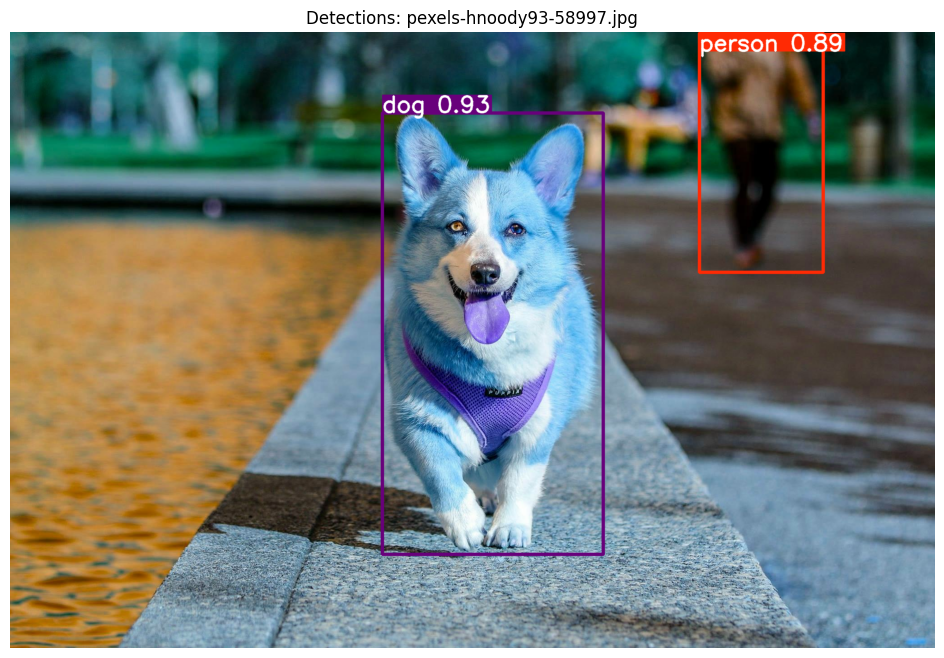


Detected objects:
  dog: 92.75%
  person: 88.74%


In [ ]:
# Upload your own image
from google.colab import files

print("Upload an image to test:")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\nRunning detection on {filename}...")
    results = model(filename)

    # Display
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(results[0].plot())
    ax.axis('off')
    ax.set_title(f'Detections: {filename}')
    plt.show()

    # Print
    print("\nDetected objects:")
    for r in results:
        for box in r.boxes:
            cls = int(box.cls[0])
            conf = float(box.conf[0])
            print(f"  {coco_classes[cls]}: {conf:.2%}")

## Summary

### Key Concepts

| Concept | Description |
|---------|-------------|
| Bounding Box | (x, y, w, h) localization |
| IoU | Overlap metric (0-1) |
| Two-stage | Propose → Classify (accurate) |
| One-stage | Direct prediction (fast) |
| YOLO | Grid-based, single pass |
| mAP | Detection accuracy metric |

### YOLOv8 Key Points

- Pretrained on COCO (80 classes)
- Easy to use: `model('image.jpg')`
- Fast: 100+ FPS
- Results contain boxes, classes, confidences
